### Exploring Host Galaxy Parameters in the DES Data Set ###

<h3> Host Galaxy Parameters (DES-SN5YR)</h3>
<p>These are the host galaxy properties provided for each SN Ia in the <code>DES-SN5YR_HD+MetaData.csv</code> file:</p>

Taken from: https://github.com/des-science/DES-SN5YR


<table style="text-align: left;">
  <thead>
    <tr>
      <th><b>Column</b></th>
      <th><b>Description</b></th>
    </tr>
  </thead>
  <tbody>
    <tr><td><code>HOST_RA</code></td><td>Right Ascension of the host galaxy (J2000).</td></tr>
    <tr><td><code>HOST_DEC</code></td><td>Declination of the host galaxy (J2000).</td></tr>
    <tr><td><code>HOST_ANGSEP</code></td><td>Angular separation between the SN and its host galaxy [arcseconds].</td></tr>
    <tr><td><code>HOST_DDLR</code></td><td>Directional light radius distance — normalized SN-host separation (unitless).</td></tr>
    <tr><td><code>HOST_ZSPEC</code></td><td>Spectroscopic redshift of the host galaxy (heliocentric frame).</td></tr>
    <tr><td><code>HOST_ZSPECERR</code></td><td>Uncertainty on the host spectroscopic redshift.</td></tr>
    <tr><td><code>VPEC</code></td><td>Host galaxy peculiar velocity [km/s].</td></tr>
    <tr><td><code>VPECERR</code></td><td>Uncertainty on the peculiar velocity [km/s].</td></tr>
    <tr><td><code>MWEBV</code></td><td>Milky Way foreground dust extinction E(B−V) along the SN line of sight.</td></tr>
    <tr><td><code>HOST_LOGMASS</code></td><td>Log<sub>10</sub> of the host galaxy stellar mass (in solar masses).</td></tr>
    <tr><td><code>HOST_LOGMASS_ERR</code></td><td>Uncertainty in the host stellar mass.</td></tr>
    <tr><td><code>HOST_COLOR</code></td><td>Rest-frame u−r color of the host galaxy (tracer of star formation history).</td></tr>
    <tr><td><code>HOST_COLOR_ERR</code></td><td>Uncertainty in the host galaxy rest-frame u−r color.</td></tr>
  </tbody>
</table>

# Loading cooridnates of host galaxies and retaining the SNID:#

In [9]:
import pandas as pd

# Load the metadata file (adjust the path as needed)
file_path = "DES-SN5YR-1.2/4_DISTANCES_COVMAT/DES-SN5YR_HD+MetaData.csv"
df = pd.read_csv(file_path)



# Extract host galaxy coordinates
host_coords = df[['CIDint', 'HOST_RA', 'HOST_DEC']].copy()

# Optionally rename for clarity
host_coords.rename(columns={
    'CIDint': 'SN_ID',
    'HOST_RA': 'SN_HOST_RA_deg',
    'HOST_DEC': 'SN_HOST_DEC_deg'
}, inplace=True)

# Display the first few entries
print(host_coords.head())

print(len(host_coords))

     SN_ID  SN_HOST_RA_deg  SN_HOST_DEC_deg
0  1246275       54.647240       -26.401073
1  1246281       53.726334       -27.622108
2  1246314       54.836571       -26.640257
3  1246527       36.019295        -5.015696
4  1246529       36.114048        -4.943895
1829


In [19]:
import pandas as pd
import numpy as np

# Load the metadata file (adjust the path as needed)
file_path = "DES-SN5YR-1.2/4_DISTANCES_COVMAT/DES-SN5YR_HD+MetaData.csv"
df = pd.read_csv(file_path)

print(np.sum((df.TYPE==1) & (df.IDSURVEY==10)))

print(np.sum((df.TYPE==0) & (df.IDSURVEY==10)))


241
1350


# Loading the mu and looking at the length #

In [10]:
import pandas as pd

# Path to the DES Hubble diagram CSV
file_path = "DES-SN5YR-1.2/4_DISTANCES_COVMAT/DES-SN5YR_HD.csv"

# Load the CSV
df_mu = pd.read_csv(file_path)

# Preview available columns
print("Available columns:", df_mu.columns.tolist())

# Extract relevant columns for SNIa distance analysis
mu_data = df_mu[['CID', 'zHD', 'zCMB', 'zHEL', 'MU', 'MUERR_FINAL']].copy()

# Rename for clarity if desired
mu_data.rename(columns={
    'CID': 'SN_ID',
    'zHD': 'z_HD',
    'zCMB': 'z_CMB',
    'zHEL': 'z_Helio',
    'MU': 'mu_obs',
    'MUERR_FINAL': 'mu_err'
}, inplace=True)

# Display first few rows
print(mu_data.head())

Available columns: ['CID', 'IDSURVEY', 'zCMB', 'zHD', 'zHEL', 'MU', 'MUERR_FINAL']
     SN_ID     z_HD    z_CMB  z_Helio   mu_obs  mu_err
0  1246275  0.24605  0.24605  0.24651  40.5938  0.0968
1  1246281  0.33549  0.33549  0.33600  41.2263  0.1360
2  1246314  0.38337  0.38337  0.38388  41.6383  0.2332
3  1246527  0.32078  0.32078  0.32184  41.1991  0.1503
4  1246529  0.49677  0.49677  0.49797  42.1471  0.1618


In [11]:
print(len(mu_data))

1829


## 🧠 Lessons on DES Host Galaxy Matching and Data Access

---

### Lesson 1: Host Matching Threshold — the dDLR Method

The **host galaxy** for each SN is assigned using the **Directional Light Radius (dDLR)** method  
([Sullivan et al. 2006](https://ui.adsabs.harvard.edu/abs/2006ApJ...648..868S), [Gupta et al. 2016](https://ui.adsabs.harvard.edu/abs/2016AJ....152..154G)).

- **dDLR** = angular distance from SN to galaxy center divided by the galaxy’s elliptical radius **in that direction**.
- The **galaxy with the smallest dDLR** is selected as the host.
- A threshold is applied:  
  **If dDLR ≤ 4 → the match is accepted**  
  **If no galaxies meet this threshold → the SN is considered *hostless***

This rule follows the convention from [D'Andrea et al. 2018](https://ui.adsabs.harvard.edu/abs/2018MNRAS.474.4994D).

---

### Lesson 2: Host Galaxy Properties from Wiseman et al. (2020)

**Paper title:**  
*Supernova Host Galaxies in the Dark Energy Survey I: Deep Coadds, Photometry, and Stellar Masses*  
**arXiv:** [arXiv:2001.02640](https://arxiv.org/abs/2001.02640)

Wiseman et al. provide deep photometry and SED-derived stellar masses for SN host galaxies in DES.  
These properties are found in **Tables B1–B4** (machine-readable online).

#### Table Column Definitions

| **Column**   | **Meaning**                                  |
|--------------|-----------------------------------------------|
| `Name`       | DES SN name (e.g. DES13E1ao)                  |
| `z`          | Redshift of the host galaxy                   |
| `g, r, i, z` | Observer-frame apparent magnitudes            |
| `g err`, etc.| Uncertainty in magnitudes                     |
| `M`          | log(Stellar mass in solar masses)             |
| `M err`      | Uncertainty in stellar mass (log scale)       |

These data were measured from DES deep coadd images and used for SED fitting (via PEGASE2 + Kroupa IMF).

---

# ------------------------------------------------------- #

# Bright Survey #

# Move on to coordinate matching of DESI Host Galaxies and DES Listed Host Galaxies - BRIGHT Survey #

# ------------------------------------------------------- #

Content of the brigth survey of the iron-main. 

HELPFUL LINKS:

Raw data files: 
https://data.desi.lbl.gov/public/dr1/

What each collumn means:
https://fastspecfit.readthedocs.io/en/stable/fastspec.html

https://fastspecfit.readthedocs.io/en/stable/fastspec.html


In [11]:
from astropy.io import fits

# Path to the FastSpecFit file
fastspecfit_path = "/global/cfs/cdirs/desi/public/dr1/vac/dr1/fastspecfit/iron/v2.1/catalogs/fastspec-iron-main-bright.fits"

# Open and inspect the FITS file
with fits.open(fastspecfit_path) as hdul:
    for i, hdu in enumerate(hdul):
        if isinstance(hdu, fits.BinTableHDU):
            columns = hdu.columns.names
            print(f"\n📁 HDU {i}: {hdu.name}")
            print("📋 Columns:")
            print(columns)
            print(len(columns))


📁 HDU 1: FASTSPEC
📋 Columns:
['TARGETID', 'SURVEY', 'PROGRAM', 'HEALPIX', 'Z', 'COEFF', 'RCHI2', 'RCHI2_CONT', 'RCHI2_PHOT', 'SNR_B', 'SNR_R', 'SNR_Z', 'SMOOTHCORR_B', 'SMOOTHCORR_R', 'SMOOTHCORR_Z', 'VDISP', 'VDISP_IVAR', 'AV', 'AGE', 'ZZSUN', 'LOGMSTAR', 'SFR', 'DN4000', 'DN4000_OBS', 'DN4000_IVAR', 'DN4000_MODEL', 'FLUX_SYNTH_G', 'FLUX_SYNTH_R', 'FLUX_SYNTH_Z', 'FLUX_SYNTH_SPECMODEL_G', 'FLUX_SYNTH_SPECMODEL_R', 'FLUX_SYNTH_SPECMODEL_Z', 'FLUX_SYNTH_PHOTMODEL_G', 'FLUX_SYNTH_PHOTMODEL_R', 'FLUX_SYNTH_PHOTMODEL_Z', 'FLUX_SYNTH_PHOTMODEL_W1', 'FLUX_SYNTH_PHOTMODEL_W2', 'FLUX_SYNTH_PHOTMODEL_W3', 'FLUX_SYNTH_PHOTMODEL_W4', 'ABSMAG10_DECAM_G', 'ABSMAG10_IVAR_DECAM_G', 'KCORR10_DECAM_G', 'ABSMAG10_DECAM_R', 'ABSMAG10_IVAR_DECAM_R', 'KCORR10_DECAM_R', 'ABSMAG10_DECAM_Z', 'ABSMAG10_IVAR_DECAM_Z', 'KCORR10_DECAM_Z', 'ABSMAG00_U', 'ABSMAG00_IVAR_U', 'KCORR00_U', 'ABSMAG00_B', 'ABSMAG00_IVAR_B', 'KCORR00_B', 'ABSMAG00_V', 'ABSMAG00_IVAR_V', 'KCORR00_V', 'ABSMAG01_SDSS_U', 'ABSMAG01_IVAR_SDSS

# View What Type of Data is in the Bright Survey #

In [1]:
from astropy.io import fits
from collections import Counter

# Path to the FITS file
fits_path = "/global/cfs/cdirs/desi/public/dr1/vac/dr1/fastspecfit/iron/v2.1/catalogs/fastspec-iron-main-bright.fits"

# Open the file and read METADATA
with fits.open(fits_path) as hdul:
    metadata = hdul["METADATA"].data
    spectypes = metadata["SPECTYPE"]
    
    # Count each unique type
    counts = Counter(spectypes)

# Print results
for stype, count in counts.items():
    print(f"{stype}: {count}")

GALAXY: 6346725
QSO: 87268
STAR: 11933


# Isolate only the data that is related to Galaxies and What I need for Analysis #

In [15]:
import time
from astropy.io import fits
from astropy.table import Table

# Paths
fits_path = "/global/cfs/cdirs/desi/public/dr1/vac/dr1/fastspecfit/iron/v2.1/catalogs/fastspec-iron-main-bright.fits"
output_path = "DES5YR_DESI_match_data/desi_galaxy_metadata.fits"

start = time.time()

# DATA NEEDED FOR ANALYSIS
with fits.open(fits_path, memmap=True) as hdul:
    metadata = Table(hdul["METADATA"].data)
    galaxy_rows = metadata[metadata["SPECTYPE"] == "GALAXY"]
    trimmed = galaxy_rows[["TARGETID", "RA", "DEC", "DESI_TARGET", "SPECTYPE", "Z", "ZWARN"]]

# Save
trimmed.write(output_path, overwrite=True)

end = time.time()
print(f"\n⏳ Total time: {end - start:.2f} seconds")

# Load and display saved file summary
with fits.open(output_path) as hdul_out:
    print(f"\n📁 Output file: {output_path}")
    print("📋 Columns:", hdul_out[1].columns.names)
    print("🧾 First few rows:")
    print(Table(hdul_out[1].data[:5]))  # display first 5 rows


⏳ Total time: 23.31 seconds

📁 Output file: DES5YR_DESI_match_data/desi_galaxy_metadata.fits
📋 Columns: ['TARGETID', 'RA', 'DEC', 'DESI_TARGET', 'SPECTYPE', 'Z', 'ZWARN']
🧾 First few rows:
    TARGETID          RA        DEC     ... SPECTYPE         Z          ZWARN
---------------- ----------- ---------- ... -------- ------------------ -----
2368701667999750 260.8449464 57.0242807 ...   GALAXY 1.4983319292975803     0
2368786908839943 134.3885965 64.2221988 ...   GALAXY   1.49658374847844     0
2368789538668549 134.1554822 64.6208963 ...   GALAXY  1.341867321039909     4
2376125435084800     322.686    -8.7557 ...   GALAXY   1.02261915483918     0
2376164282728448    137.4895    -6.9718 ...   GALAXY 1.0253667671522346     0


# Matching DES-SN Host Galaxies to DESI Galaxies (1 arcsec tolerance)

Perform a positional cross-match between Type Ia supernova (SN Ia) host galaxies from the **DES 5YR dataset** and galaxies from the **DESI survey**, using a maximum angular separation of **1 arcsecond**.

In [3]:
import pandas as pd
from astropy.io import fits
from astropy.coordinates import SkyCoord
import astropy.units as u
from astropy.table import Table, hstack

# Load DES 5YR CSV
des_sn_hostgal = pd.read_csv("DES-SN5YR-1.2/4_DISTANCES_COVMAT/DES-SN5YR_HD+MetaData.csv")

# Filter out invalid coordinates
valid_mask = (
    (des_sn_hostgal["HOST_DEC"] > -90) & (des_sn_hostgal["HOST_DEC"] < 90) &
    (des_sn_hostgal["HOST_RA"] >= 0) & (des_sn_hostgal["HOST_RA"] < 360)
)
des_sn_valid = des_sn_hostgal[valid_mask]

# Create SkyCoord objects
sn_coords = SkyCoord(ra=des_sn_valid["HOST_RA"].values * u.deg,
                     dec=des_sn_valid["HOST_DEC"].values * u.deg)

# Load DESI galaxy data
with fits.open("DES5YR_DESI_match_data/desi_galaxy_metadata.fits") as hdul:
    desi_data = Table(hdul[1].data)
    desi_coords = SkyCoord(ra=desi_data["RA"] * u.deg,
                           dec=desi_data["DEC"] * u.deg)

# Match SN hosts to nearest DESI galaxy
idx, sep2d, _ = sn_coords.match_to_catalog_sky(desi_coords)

# Filter matches within 30 arcsec
max_sep = 1 * u.arcsec
mask = sep2d < max_sep

# Extract matched rows
matched_sn = Table.from_pandas(des_sn_valid[mask])
matched_desi = desi_data[idx[mask]]

# Join tables and save
matched = hstack([matched_sn, matched_desi])
matched.write("DES5YR_DESI_match_data/desi_matched_sn.fits", overwrite=True)
matched.write("DES5YR_DESI_match_data/desi_matched_sn.csv", format="csv", overwrite=True)

print(f"✅ Matched {len(matched)} SN-host pairs within 1 arcsec.")


with fits.open("DES5YR_DESI_match_data/desi_matched_sn.fits") as hdul:
    # Print basic info about the HDU
    hdul.info()

    # Load the table
    data = Table(hdul[1].data)

# Show column na

✅ Matched 80 SN-host pairs within 1 arcsec.
Filename: DES5YR_DESI_match_data/desi_matched_sn.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1                1 BinTableHDU    122   80R x 57C   [7A, K, K, K, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, K, D, D, D, D, D, D, D, D, D, D, D, D, K, D, D, K, 6A, D, K]   

📋 Columns: ['CID', 'CIDint', 'IDSURVEY', 'TYPE', 'zHEL', 'zHELERR', 'zCMB', 'zCMBERR', 'zHD', 'zHDERR', 'VPEC', 'VPECERR', 'MWEBV', 'HOST_ZSPEC', 'HOST_ZSPECERR', 'HOST_RA', 'HOST_DEC', 'HOST_ANGSEP', 'HOST_DDLR', 'HOST_LOGMASS', 'HOST_LOGMASS_ERR', 'HOST_COLOR', 'HOST_COLOR_ERR', 'PKMJD', 'PKMJDERR', 'x1', 'x1ERR', 'c', 'cERR', 'mB', 'mBERR', 'mB_corr', 'x0', 'x0ERR', 'COV_x1_c', 'COV_x1_x0', 'COV_c_x0', 'NDOF', 'FITPROB', 'PROB_SCONE', 'PROB_SNIRFV19', 'PROB_SNNDESCC', 'PROB_SNNJ17', 'PROB_SNNV19', 'MU', 'MUERR_FINAL', 'PROBCC_BEAMS', 'biasCor_mu', 

# Matching DES-SN Host Galaxies to DESI Galaxies (range of arcseconds)

Perform a positional cross-match between Type Ia supernova (SN Ia) host galaxies from the **DES 5YR dataset** and galaxies from the **DESI survey**, using a maximum angular separation of **1 arcsecond**.

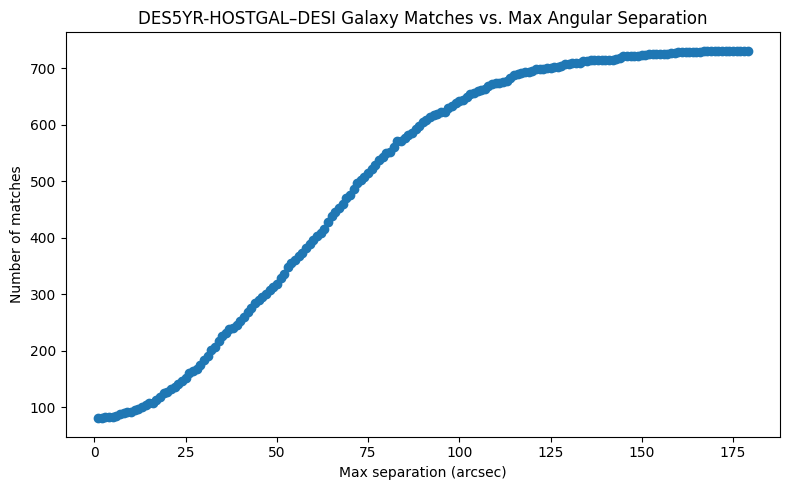


⏱️ Runtime: 5.29 seconds


In [3]:
import time
import pandas as pd
from astropy.io import fits
from astropy.coordinates import SkyCoord
import astropy.units as u
from astropy.table import Table
import matplotlib.pyplot as plt

start = time.time()

# Load DES 5YR CSV
des_sn_hostgal = pd.read_csv("DES-SN5YR-1.2/4_DISTANCES_COVMAT/DES-SN5YR_HD+MetaData.csv")

# Filter out invalid coordinates
valid_mask = (
    (des_sn_hostgal["HOST_DEC"] > -90) & (des_sn_hostgal["HOST_DEC"] < 90) &
    (des_sn_hostgal["HOST_RA"] >= 0) & (des_sn_hostgal["HOST_RA"] < 360)
)

des_sn_valid = des_sn_hostgal[valid_mask]



# Create SkyCoord objects
sn_coords = SkyCoord(ra=des_sn_valid["HOST_RA"].values * u.deg,
                     dec=des_sn_valid["HOST_DEC"].values * u.deg)

# Load DESI galaxy data
with fits.open("DES5YR_DESI_match_data/desi_galaxy_metadata.fits") as hdul:
    desi_data = Table(hdul[1].data)
    desi_coords = SkyCoord(ra=desi_data["RA"] * u.deg,
                           dec=desi_data["DEC"] * u.deg)

# Match SN hosts to nearest DESI galaxy
idx, sep2d, _ = sn_coords.match_to_catalog_sky(desi_coords)

# Loop through thresholds and count matches
arcsec_range = range(1, 180)

match_counts = []
# Loop through each maximum angular separation threshold (in arcseconds)
for arcsec in arcsec_range:
    # Define the current maximum separation as an astropy quantity
    max_sep = arcsec * u.arcsec

    # Create a boolean mask: True for SNe matched within this max separation
    mask = sep2d < max_sep

    # Count how many True values (i.e., how many matches)
    num_matches = mask.sum()

    # Store the count for this threshold
    match_counts.append(num_matches)

# Plot
plt.figure(figsize=(8, 5))
plt.plot(arcsec_range, match_counts, marker='o')
plt.title("DES5YR-HOSTGAL–DESI Galaxy Matches vs. Max Angular Separation")
plt.xlabel("Max separation (arcsec)")
plt.ylabel("Number of matches")
plt.tight_layout()
plt.show()

end = time.time()
print(f"\n⏱️ Runtime: {end - start:.2f} seconds")

In [12]:
import pandas as pd
from astropy.io import fits
from astropy.coordinates import SkyCoord
import astropy.units as u
from astropy.table import Table, hstack

# Load DES 5YR CSV
des_sn = pd.read_csv("DES-SN5YR-1.2/4_DISTANCES_COVMAT/DES-SN5YR_HD+MetaData.csv")

# Filter out invalid coordinates
valid_mask = (
    (des_sn_hostgal["HOST_DEC"] > -90) & (des_sn_hostgal["HOST_DEC"] < 90) &
    (des_sn_hostgal["HOST_RA"] >= 0) & (des_sn_hostgal["HOST_RA"] < 360)
)
des_sn_valid = des_sn_hostgal[valid_mask]

# Create SkyCoord objects
sn_coords = SkyCoord(ra=des_sn_valid["HOST_RA"].values * u.deg,
                     dec=des_sn_valid["HOST_DEC"].values * u.deg)

# Load DESI galaxy data
with fits.open("DES5YR_DESI_match_data/desi_galaxy_metadata.fits") as hdul:
    desi_data = Table(hdul[1].data)
    desi_coords = SkyCoord(ra=desi_data["RA"] * u.deg,
                           dec=desi_data["DEC"] * u.deg)

# Match SN hosts to nearest DESI galaxy
idx, sep2d, _ = sn_coords.match_to_catalog_sky(desi_coords)

# Filter matches within 30 arcsec
max_sep = 5 * u.arcsec
mask = sep2d < max_sep

# Extract matched rows
matched_sn = Table.from_pandas(des_sn_valid[mask])
matched_desi = desi_data[idx[mask]]

# Join tables and save
matched = hstack([matched_sn, matched_desi])
matched.write("DES5YR_DESI_match_data/desi_matched_sn.fits", overwrite=True)

print(f"✅ Matched {len(matched)} SN-host and DESI galaxy pairs")

✅ Matched 83 SN-host and DESI galaxy pairs


# REdshift verification Comparison of all z's of the matched SN_HostGal and DESI Coordinates #

Here is a link that says Z in DESI is spectroscopic:
https://data.desi.lbl.gov/doc/glossary/?utm_source=chatgpt.com

Direct quote: 

Redrock - The spectroscopic classification and redshift fitting pipeline for DESI spectra.

Z - Redshift based on Redrock or QuasarNet (for QSO targets only).

ZWARN - Redrock zwarning bit.

# PRinting S2d to see what is going on and how bad it gets #


# Do matching for SNIa that Is Missing HostGalaxy Informaiton #

So when we look at the IDSURVEY at the following link: https://des-sn-dr.readthedocs.io/en/latest/4_DISTANCES_COVMAT.html


IDSURVEY - {10:'DES', 61:'CFA1', 62:'CFA2', 63:'CFA3S', 64:'CFA3K' ,65:'CFA4p2', 66:'CFA4p3', 150:'FOUND'}

The surveys that do not have hostgalaxy information label their host galaxy coordiantes as -999,-999 for RA AND DEC.

Since the missing hostgalaxy data is varied, instead of hunting down each survey, we will just do positional matching here as I did for Jeffs final project: making sure to keep Host galaxy and SNIa within 4 Half Light radii. 

Please see the following from the paper:

The **host galaxy** for each SN is assigned using the **Directional Light Radius (dDLR)** method  
([Sullivan et al. 2006](https://ui.adsabs.harvard.edu/abs/2006ApJ...648..868S), [Gupta et al. 2016](https://ui.adsabs.harvard.edu/abs/2016AJ....152..154G)).

- **dDLR** = angular distance from SN to galaxy center divided by the galaxy’s elliptical radius **in that direction**.
- The **galaxy with the smallest dDLR** is selected as the host.
- A threshold is applied:  
  **If dDLR ≤ 4 → the match is accepted**  
  **If no galaxies meet this threshold → the SN is considered *hostless***

# Missing Host Galaxy Data from Hodgepodge of Surveys #

# ------------------------------------------------------- #

# Going to the Drak Survey #

# ------------------------------------------------------- #


In [1]:
from astropy.io import fits

# Path to the FastSpecFit file
fastspecfit_path = "/global/cfs/cdirs/desi/public/dr1/vac/dr1/fastspecfit/iron/v2.1/catalogs/fastspec-iron-main-dark.fits"

# Open and inspect the FITS file
with fits.open(fastspecfit_path) as hdul:
    for i, hdu in enumerate(hdul):
        if isinstance(hdu, fits.BinTableHDU):
            columns = hdu.columns.names
            print(f"\n📁 HDU {i}: {hdu.name}")
            print("📋 Columns:")
            print(columns)
            print(len(columns))


📁 HDU 1: FASTSPEC
📋 Columns:
['TARGETID', 'SURVEY', 'PROGRAM', 'HEALPIX', 'Z', 'COEFF', 'RCHI2', 'RCHI2_CONT', 'RCHI2_PHOT', 'SNR_B', 'SNR_R', 'SNR_Z', 'SMOOTHCORR_B', 'SMOOTHCORR_R', 'SMOOTHCORR_Z', 'VDISP', 'VDISP_IVAR', 'AV', 'AGE', 'ZZSUN', 'LOGMSTAR', 'SFR', 'DN4000', 'DN4000_OBS', 'DN4000_IVAR', 'DN4000_MODEL', 'FLUX_SYNTH_G', 'FLUX_SYNTH_R', 'FLUX_SYNTH_Z', 'FLUX_SYNTH_SPECMODEL_G', 'FLUX_SYNTH_SPECMODEL_R', 'FLUX_SYNTH_SPECMODEL_Z', 'FLUX_SYNTH_PHOTMODEL_G', 'FLUX_SYNTH_PHOTMODEL_R', 'FLUX_SYNTH_PHOTMODEL_Z', 'FLUX_SYNTH_PHOTMODEL_W1', 'FLUX_SYNTH_PHOTMODEL_W2', 'FLUX_SYNTH_PHOTMODEL_W3', 'FLUX_SYNTH_PHOTMODEL_W4', 'ABSMAG10_DECAM_G', 'ABSMAG10_IVAR_DECAM_G', 'KCORR10_DECAM_G', 'ABSMAG10_DECAM_R', 'ABSMAG10_IVAR_DECAM_R', 'KCORR10_DECAM_R', 'ABSMAG10_DECAM_Z', 'ABSMAG10_IVAR_DECAM_Z', 'KCORR10_DECAM_Z', 'ABSMAG00_U', 'ABSMAG00_IVAR_U', 'KCORR00_U', 'ABSMAG00_B', 'ABSMAG00_IVAR_B', 'KCORR00_B', 'ABSMAG00_V', 'ABSMAG00_IVAR_V', 'KCORR00_V', 'ABSMAG01_SDSS_U', 'ABSMAG01_IVAR_SDSS

# Lets See What Type of Data The Dark Survey Has #

In [4]:
from astropy.io import fits
from collections import Counter

# Path to the FITS file
fits_path = "/global/cfs/cdirs/desi/public/dr1/vac/dr1/fastspecfit/iron/v2.1/catalogs/fastspec-iron-main-dark.fits"

# Open the file and read METADATA
with fits.open(fits_path) as hdul:
    metadata = hdul["METADATA"].data
    spectypes = metadata["SPECTYPE"]
    
    # Count each unique type
    counts = Counter(spectypes)

# Print results
for stype, count in counts.items():
    print(f"{stype}: {count}")

GALAXY: 8490171
STAR: 8026
QSO: 1577360


# Lets Only Isolate Galaxy Related Data #

In [5]:
import time
from astropy.io import fits
from astropy.table import Table

# Paths
fits_path = "/global/cfs/cdirs/desi/public/dr1/vac/dr1/fastspecfit/iron/v2.1/catalogs/fastspec-iron-main-dark.fits"
output_path = "DES5YR_DESI_match_data/desi_galaxy_metadata_dark.fits"

start = time.time()

# Load and filter
with fits.open(fits_path, memmap=True) as hdul:
    metadata = Table(hdul["METADATA"].data)
    galaxy_rows = metadata[metadata["SPECTYPE"] == "GALAXY"]
    trimmed = galaxy_rows[["TARGETID", "RA", "DEC", "DESI_TARGET", "SPECTYPE", "Z", "ZWARN"]]

# Save
trimmed.write(output_path, overwrite=True)

end = time.time()
print(f"\n⏳ Total time: {end - start:.2f} seconds")

# Load and display saved file summary
with fits.open(output_path) as hdul_out:
    print(f"\n📁 Output file: {output_path}")
    print("📋 Columns:", hdul_out[1].columns.names)
    print("🧾 First few rows:")
    print(Table(hdul_out[1].data[:5]))  # display first 5 rows


⏳ Total time: 48.16 seconds

📁 Output file: DES5YR_DESI_match_data/desi_galaxy_metadata_dark.fits
📋 Columns: ['TARGETID', 'RA', 'DEC', 'DESI_TARGET', 'SPECTYPE', 'Z', 'ZWARN']
🧾 First few rows:
    TARGETID         RA       DEC    ... SPECTYPE          Z           ZWARN
---------------- ---------- -------- ... -------- -------------------- -----
2204596575404032   18.56004 -8.77222 ...   GALAXY   0.9202756422177001     4
2204652607111168  145.31148 -6.51893 ...   GALAXY   0.0164122219415028     0
2204712820539392  146.92907 -3.97609 ...   GALAXY 0.016040666875158115     0
2204728519819264 3.91221999  -3.1253 ...   GALAXY   0.4539994243815054     4
2204743308935168  165.80074 -2.83891 ...   GALAXY  0.03227592971739598     4


# 1 ArcSecond Match #

In [7]:
import pandas as pd
from astropy.io import fits
from astropy.coordinates import SkyCoord
import astropy.units as u
from astropy.table import Table, hstack

# Load DES 5YR CSV
des_sn_hostgal = pd.read_csv("DES-SN5YR-1.2/4_DISTANCES_COVMAT/DES-SN5YR_HD+MetaData.csv")

# Filter out invalid coordinates
valid_mask = (
    (des_sn_hostgal["HOST_DEC"] > -90) & (des_sn_hostgal["HOST_DEC"] < 90) &
    (des_sn_hostgal["HOST_RA"] >= 0) & (des_sn_hostgal["HOST_RA"] < 360)
)
des_sn_valid = des_sn_hostgal[valid_mask]

# Create SkyCoord objects
sn_coords = SkyCoord(ra=des_sn_valid["HOST_RA"].values * u.deg,
                     dec=des_sn_valid["HOST_DEC"].values * u.deg)

# Load DESI galaxy data
with fits.open("DES5YR_DESI_match_data/desi_galaxy_metadata_dark.fits") as hdul:
    desi_data = Table(hdul[1].data)
    desi_coords = SkyCoord(ra=desi_data["RA"] * u.deg,
                           dec=desi_data["DEC"] * u.deg)

# Match SN hosts to nearest DESI galaxy
idx, sep2d, _ = sn_coords.match_to_catalog_sky(desi_coords)

# Filter matches within 30 arcsec
max_sep = 1 * u.arcsec
mask = sep2d < max_sep

# Extract matched rows
matched_sn = Table.from_pandas(des_sn_valid[mask])
matched_desi = desi_data[idx[mask]]

# Join tables and save
matched = hstack([matched_sn, matched_desi])
matched.write("DES5YR_DESI_match_data/desi_matched_sn_dark.fits", overwrite=True)
matched.write("DES5YR_DESI_match_data/desi_matched_sn_dark.csv", format="csv", overwrite=True)

print(f"✅ Matched {len(matched)} SN-host pairs within 1 arcsec.")


with fits.open("DES5YR_DESI_match_data/desi_matched_sn_dark.fits") as hdul:
    # Print basic info about the HDU
    hdul.info()

    # Load the table
    data = Table(hdul[1].data)

# Show column na

✅ Matched 38 SN-host pairs within 1 arcsec.
Filename: DES5YR_DESI_match_data/desi_matched_sn_dark.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1                1 BinTableHDU    122   38R x 57C   [7A, K, K, K, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, K, D, D, D, D, D, D, D, D, D, D, D, D, K, D, D, K, 6A, D, K]   


# Matching DES-SN Host Galaxies to DESI Galaxies (range of arcseconds)

Perform a positional cross-match between Type Ia supernova (SN Ia) host galaxies from the **DES 5YR dataset** and galaxies from the **DESI survey**, using a maximum angular separation of **1 arcsecond**.

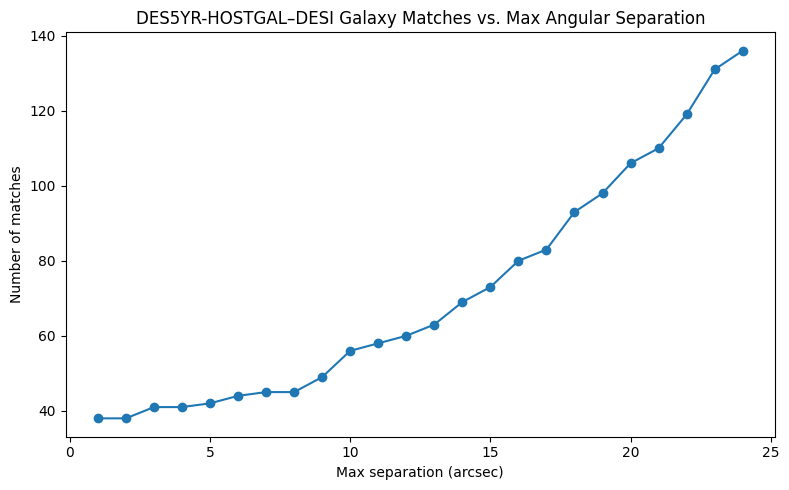


⏱️ Runtime: 7.75 seconds


In [10]:
import time
import pandas as pd
from astropy.io import fits
from astropy.coordinates import SkyCoord
import astropy.units as u
from astropy.table import Table
import matplotlib.pyplot as plt

start = time.time()

# Load DES 5YR CSV
des_sn_hostgal = pd.read_csv("DES-SN5YR-1.2/4_DISTANCES_COVMAT/DES-SN5YR_HD+MetaData.csv")

# Filter out invalid coordinates
valid_mask = (
    (des_sn_hostgal["HOST_DEC"] > -90) & (des_sn_hostgal["HOST_DEC"] < 90) &
    (des_sn_hostgal["HOST_RA"] >= 0) & (des_sn_hostgal["HOST_RA"] < 360)
)

des_sn_valid = des_sn_hostgal[valid_mask]



# Create SkyCoord objects
sn_coords = SkyCoord(ra=des_sn_valid["HOST_RA"].values * u.deg,
                     dec=des_sn_valid["HOST_DEC"].values * u.deg)

# Load DESI galaxy data
with fits.open("DES5YR_DESI_match_data/desi_galaxy_metadata_dark.fits") as hdul:
    desi_data = Table(hdul[1].data)
    desi_coords = SkyCoord(ra=desi_data["RA"] * u.deg,
                           dec=desi_data["DEC"] * u.deg)

# Match SN hosts to nearest DESI galaxy
idx, sep2d, _ = sn_coords.match_to_catalog_sky(desi_coords)

# Loop through thresholds and count matches
arcsec_range = range(1, 25)

match_counts = []
# Loop through each maximum angular separation threshold (in arcseconds)
for arcsec in arcsec_range:
    # Define the current maximum separation as an astropy quantity
    max_sep = arcsec * u.arcsec

    # Create a boolean mask: True for SNe matched within this max separation
    mask = sep2d < max_sep

    # Count how many True values (i.e., how many matches)
    num_matches = mask.sum()

    # Store the count for this threshold
    match_counts.append(num_matches)

# Plot
plt.figure(figsize=(8, 5))
plt.plot(arcsec_range, match_counts, marker='o')
plt.title("DES5YR-HOSTGAL–DESI Galaxy Matches vs. Max Angular Separation")
plt.xlabel("Max separation (arcsec)")
plt.ylabel("Number of matches")
plt.tight_layout()
plt.show()

end = time.time()
print(f"\n⏱️ Runtime: {end - start:.2f} seconds")